# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 20. Обучение LLM`

## `Занятие провел: Марьясов Максим (tg: @oop_clon)`

## `Материалы составили: Марьясов Максим (tg: @oop_clon), Богачев Владимир (tg: @bogachevvTG)`


### `Москва, Весенний семестр 2026`

Источники:

- **Attention Is All You Need**: [Ashish Vaswani et al., 2017](https://arxiv.org/abs/1706.03762), примерно 240,000 цитирований &ndash; оригинальная работа, представившая архитектуру Transformer, которая стала основой всех современных LLM  

- **Deep Reinforcement Learning from Human Preferences**: [Paul Christiano et al., 2017](https://arxiv.org/abs/1706.03741), примерно 7,000 цитирований &ndash; базовый подход к обучению через человеческие предпочтения, лежащий в основе RLHF  

- **Improving Language Understanding by Generative Pre-Training (GPT)**: [Alec Radford et al., 2018](https://openai.com/research/language-unsupervised), примерно 20,000 цитирований &ndash; введение подхода generative pre-training: предобучение языковой модели с последующим fine-tuning под задачи  

- **Language Models are Unsupervised Multitask Learners (GPT-2)**: [Alec Radford et al., 2019](https://openai.com/research/better-language-models), примерно 24,000 цитирований &ndash; демонстрация того, что крупные языковые модели могут решать множество задач в zero-shot режиме без явного обучения на них  

- **Language Models are Few-Shot Learners**: [Tom B. Brown et al., 2020](https://arxiv.org/abs/2005.14165), примерно 70,000 цитирований &ndash; статья про GPT-3, где показано, что масштабирование моделей приводит к появлению in-context learning и позволяет решать задачи без fine-tuning  

- **Scaling Laws for Neural Language Models**: [Jared Kaplan et al., 2020](https://arxiv.org/abs/2001.08361), примерно 8,000 цитирований &ndash; эмпирические законы масштабирования: качество моделей предсказуемо улучшается при увеличении параметров, данных и вычислений

- **Training Compute-Optimal Large Language Models (Chinchilla)**: [Jordan Hoffmann et al., 2022](https://arxiv.org/abs/2203.15556), примерно цитирований &ndash; показано, что важен баланс между размером модели и объёмом данных; предложены compute-optimal scaling laws

- **Training language models to follow instructions with human feedback (InstructGPT)**: [Long Ouyang et al., 2022](https://arxiv.org/abs/2203.02155), примерно 24,000 цитирований &ndash;формализация RLHF-пайплайна: SFT $\to$ reward model $\to$ PPO для выравнивания модели с человеческими предпочтениями  

- **LLaMA: Open and Efficient Foundation Language Models**: [Hugo Touvron et al., 2023](https://arxiv.org/abs/2302.13971), примерно 25,000 цитирований &ndash; представлена линейка LLaMA: эффективные фундаментальные модели

- **Direct Preference Optimization (DPO)**: [Rafael Rafailov et al., 2023](https://arxiv.org/abs/2305.18290), примерно 8,500 цитирований &ndash; альтернатива RLHF без отдельной reward-модели и RL, сводящая обучение к прямой оптимизации предпочтений

- **Why Can GPT Learn In-Context? Language Models Secretly Perform Gradient Descent as Meta-Optimizers**: [Damai Dai et al., 2022](https://arxiv.org/abs/2212.10559), примерно 330 цитирований &ndash; показывают, что механизм attention в трансформере имеет двойственную форму с градиентным спуском: модель порождает мета-градиенты на основе демонстрационных примеров и применяет их для построения ICL-модели

- **Transformers Learn In-Context by Gradient Descent**: [Johannes von Oswald, et al., 2022](https://arxiv.org/abs/2212.07677), примерно 230 цитирований &ndash; доказывают эквивалентность преобразований одного слоя linear self-attention и шага градиентного спуска на регрессионном лоссе; показывают, что трансформеры превосходят обычный GD за счёт обучения итеративной коррекции кривизны

---

Цель данной лекции &ndash; разобрать полный цикл обучения современных LLM (Large Language Models): от предобучения на больших текстовых корпусах до дообучения под инструкции и выравнивания поведения модели под предпочтения человека.

В течение лекции мы узнаем следующее:

*  как формируется базовая языковая модель;
*  как обучить модель, чтобы она следовала нашим инструкциям;
*  почему правильный ответ не всегда хороший, и как научить модель их разделять;
*  как научить модель отвечать правильно без обучения;
*  как заставить модель думать перед ответом



---

## Введение

### Напоминание: Архитектура трансформера

На предыдущих лекциях была разобрана архитектура трансформера, начиная с работы **Attention is all you need**: [Ashish Vaswani et al., 2017](https://arxiv.org/abs/1706.03762) и её основных компонентов.

Также были рассмотрены её ключевые варианты:
- GPT (decoder-only)
- BERT (encoder-only)
- seq2seq модели (например, T5)


В этой лекции мы не будем подробно разбирать архитектуру. Вместо этого сосредоточимся на вопросе: **как обучаются современные LLM** &ndash; начиная с предобучения и заканчивая выравниванием поведения модели под предпочтения человека.

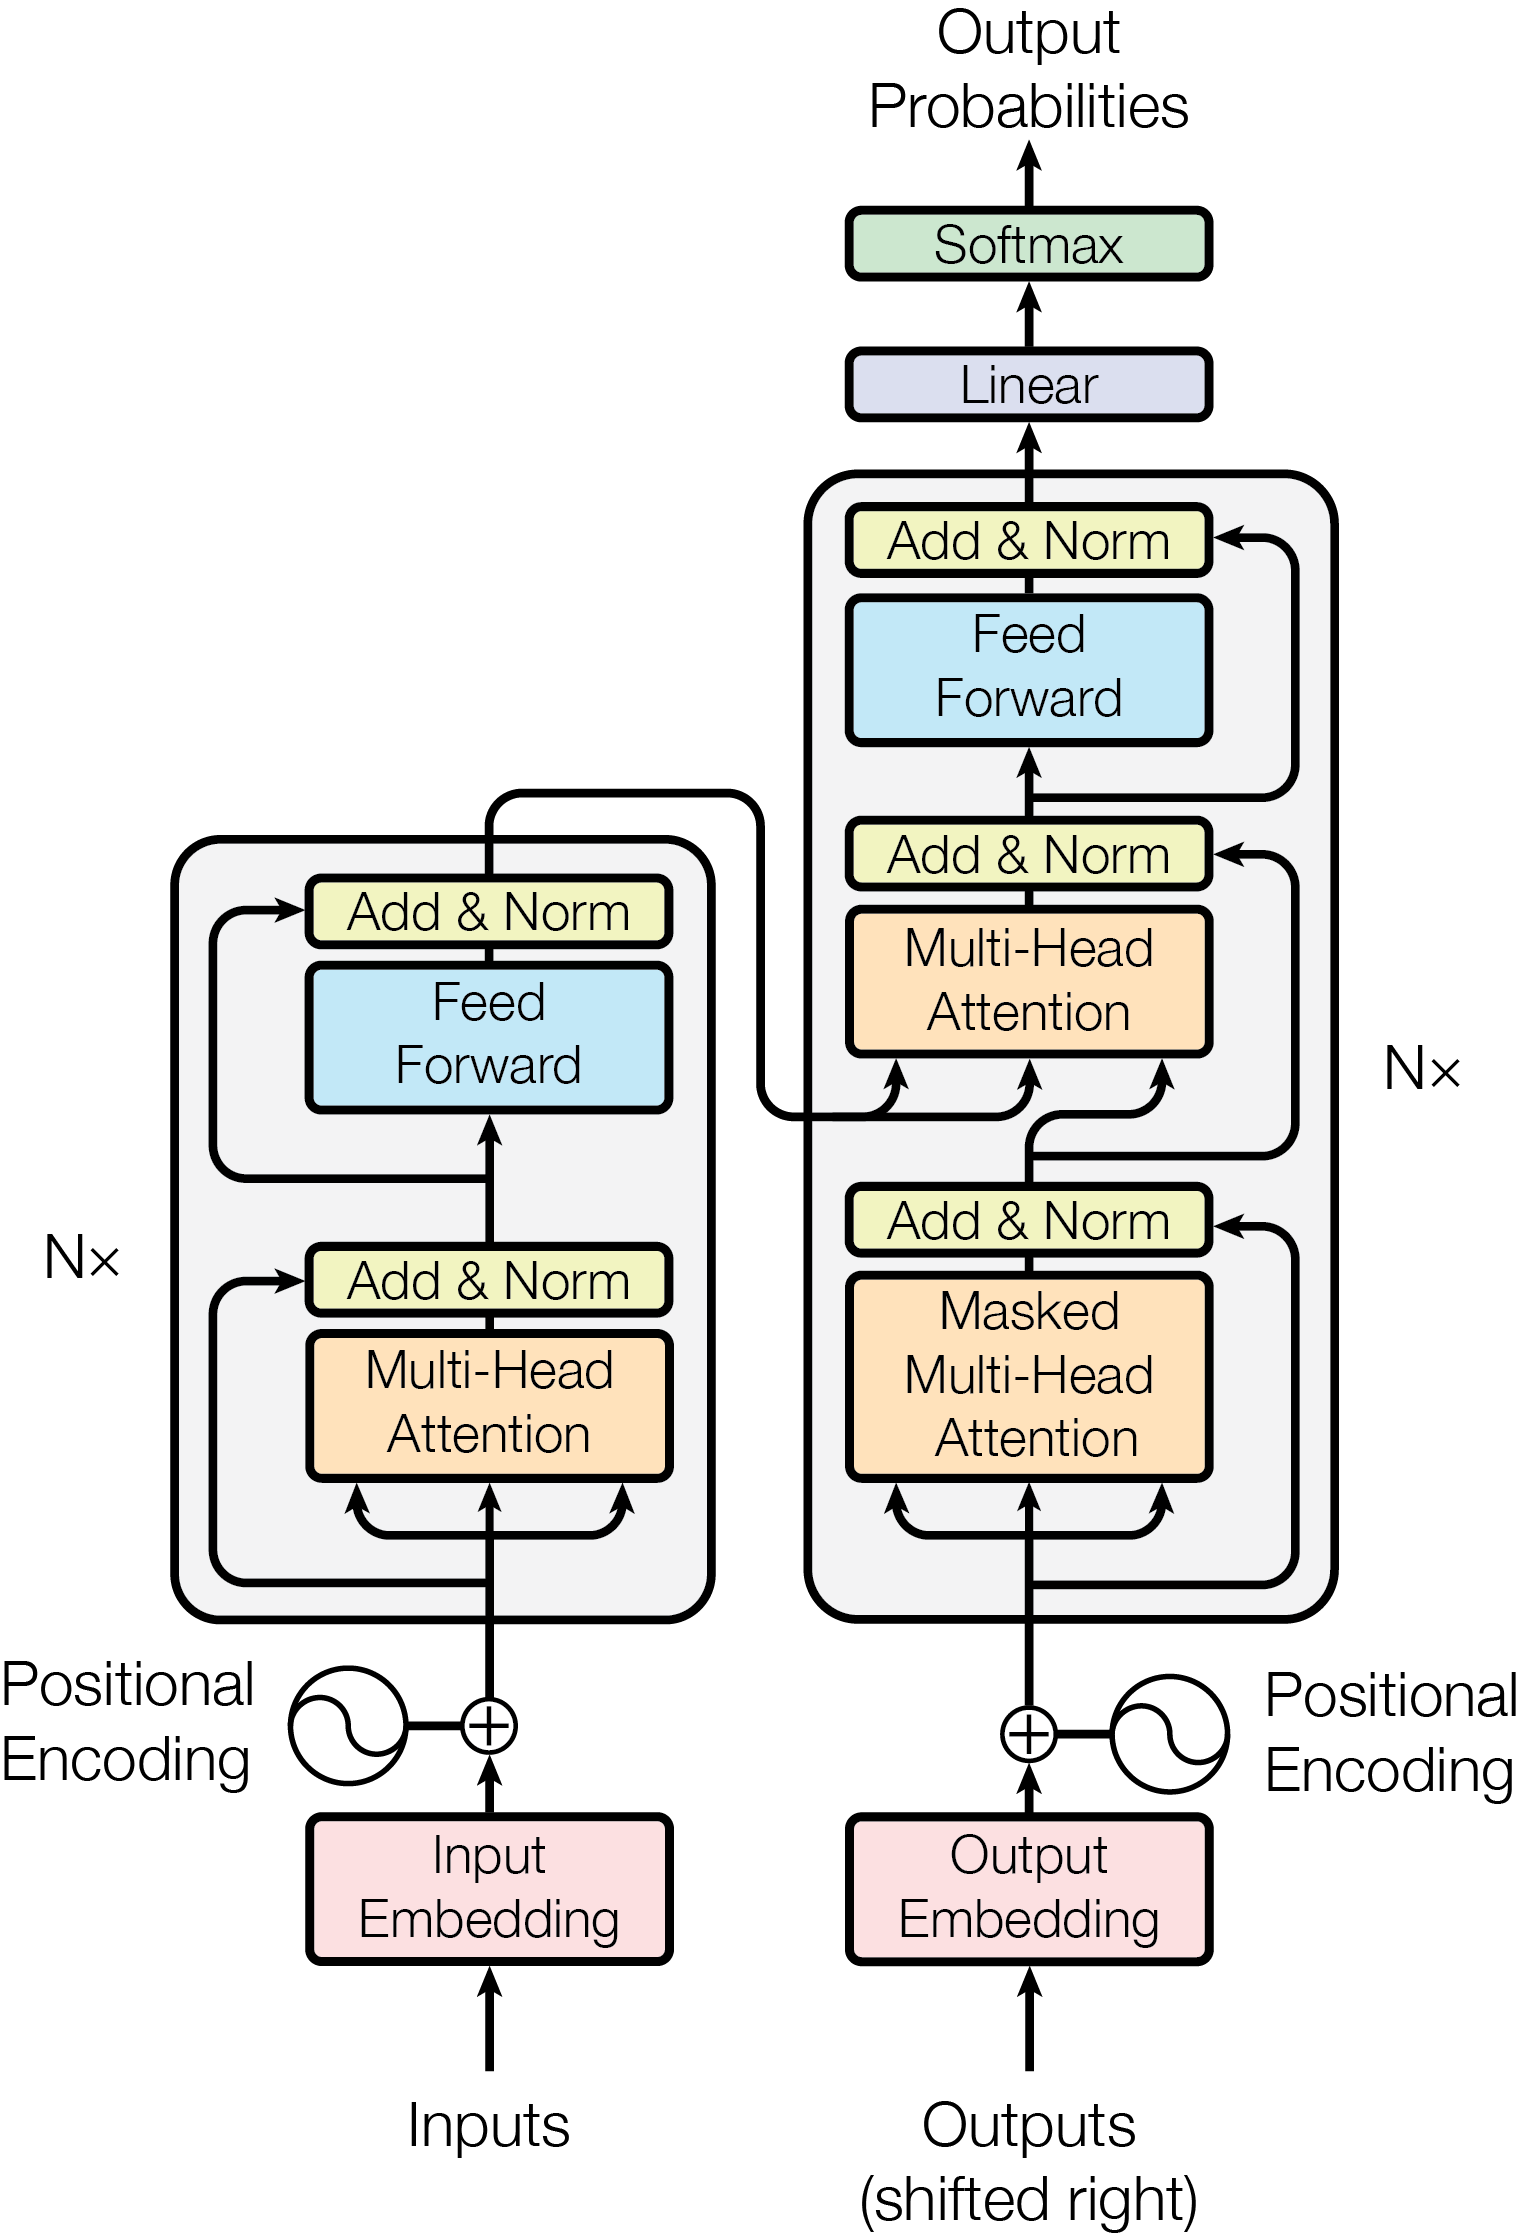

<font color='Orange'>**Вопрос:**</font> Зачем нужны задачи Masked Language Modeling (MLM), Next Sentence Prediction (NSP) и Next Token Prediction (NTP)?

#### Ответ:

Они нужны для предобучения (pre-training), чтобы научить модель языку без разметки.

* **MLM** &ndash; учит извлекать смысл из контекста
* **NSP** &ndash; учит структуре текста
* **NTP** &ndash; учит моделировать распределение языка

Это задачи, которые превращают сырой текст в знания о языке, пригодные для downstream-задач.

## Предобучение модели

**Pre-training** &ndash; это первый и наиболее ресурсоёмкий этап обучения больших языковых моделей (LLM).

Идея предобучения не уникальна для NLP. **В компьютерном зрении** этот подход давно стал стандартом: модель сначала обучается на большом датасете (например, ImageNet), а затем адаптируется к конкретной задаче путём замены выходного слоя и дообучения (fine-tuning).

<font color='Red'>**Важно:**</font> В NLP предобучение происходит на масштабных текстовых корпусах в режиме **без учителя (unsupervised / self-supervised learning)**. Модель обучается на текстах из интернета, книг, научных статей, репозиториев с кодом и других источников. В процессе предобучения модель осваивает языковые структуры и накапливает знания о мире.

<font color='Red'>**Важно:**</font> **Цель предобучения &ndash; получить базовую языковую модель**, которая хорошо моделирует распределение естественного языка.

Что это значит на практике? Мы хотим, чтобы модель, "прочитав" огромное количество текстов, научилась:

* понимать грамматику и синтаксис языка,
* улавливать семантические связи между словами и понятиями,
* усваивать фактические знания о мире,
* моделировать логические и причинно-следственные связи.

Для предобучения текстовых моделей используются разные задачи:

1. **Causal Language Modeling (CLM)** &ndash; задача предсказания следующего токена по предыдущим токенам \
**Примеры моделей:** GPT, GPT-2, GPT-3, LLaMA

2. **Masked Language Modeling (MLM)** &ndash; часть токенов заменяется на [MASK], и модель восстанавливает их по контексту слева и справа \
**Примеры моделей:** BERT, RoBERTa

3. **Next Sentence Prediction (NSP)** &ndash; задача бинарной классификации, где модель определяет, следует ли предложение B за предложением A \
**Пример модели:** BERT

В данной лекции мы сосредоточимся на CLM, так как именно этот подход лежит в основе обучение современных LLM. Напомним его с прошлых лекций:

**Математическая формулировка CLM**

CLM (Causal Language Modeling) &ndash; это постановка задачи, в которой модель учится предсказывать следующий токен в последовательности, используя прошлые токены.

Пусть дана последовательность токенов:
$$ x = (x_1, x_2, \dots, x_T). $$

Мы хотим моделировать вероятность всей последовательности:
$$ P(x_1, x_2, \dots, x_T). $$


В языковых моделях вводится структурное ограничение: предсказание на шаге t зависит только от прошлого контекста. Это соответствует направленной генерации текста слева направо:

$$ P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_{<t}), $$ 
где $x_{<t} = (x_1, x_2, \dots, x_{t-1})$

Обучение формулируется как максимизация вероятности наблюдаемых данных. Эквивалентно &ndash; максимизация логарифма правдоподобия:

$$
\max_\theta \sum_{t=1}^{T} \log P_\theta(x_t \mid x_{<t}).
$$

На практике оптимизируется отрицательное лог-правдоподобие (NLL), которое удобно интерпретировать как среднюю ошибку предсказания:

$$
L(\theta) = - \sum_{t=1}^{T} \log P_\theta(x_t \mid x_{<t}).
$$


Часто используют нормировку по длине последовательности, чтобы сделать значение сравнимым между текстами разной длины:

$$
L(\theta) = - \frac{1}{T} \sum_{t=1}^{T} \log P_\theta(x_t \mid x_{<t}).
$$

**Как оценивать языковую модель**

Для оценки качества языковой модели используется перплексия.

Перплексия (Perplexity, PPL) определяется как:

$$
PPL = \exp\left(\frac{1}{T} \sum_{t=1}^{T} -\log P_\theta(x_t \mid x_{<t})\right).
$$

Эквивалентно через значение функции потерь:

$$
PPL = \exp\left(\frac{L(\theta)}{T}\right).
$$

Её можно интерпретировать, как среднюю неопределённость модели при предсказании следующего токена.

Но у неё есть свои ограничения &ndash; она не оценивает связность, логику и соотвествие цели пользователя и т.д., поэтому её используют только на этапе pre-training.

**Аналогия с компьютерным зрением**

В компьютерном зрении исторически использовались **размеченные датасеты** (например, ImageNet), однако в современных подходах всё чаще применяется **self-supervised pre-training на неразмеченных данных**, аналогично NLP.

**Задача pre-training** в CV не ограничивается классификацией. Сегодня используются:
- **contrastive learning** &ndash; модель сближает представления одного и того же изображения (разные аугментации) и разделяет разные изображения

- **masked image modeling** &ndash; часть изображения скрывается, и модель должна восстановить недостающие области по контексту (аналог masked language modeling в NLP)  

- **multimodal обучение** &ndash; модель учится связывать разные модальности (например, изображение и текст), сопоставляя их представления

Это делает постановку близкой к NLP, где применяется **self-supervised задача предсказания токенов** (CLM/MLM).

В процессе обучения модели извлекают разные типы представлений:
- в CV &ndash; **визуальные признаки** (от низкоуровневых паттернов до объектов и сцен),
- в NLP &ndash; **языковые структуры и семантику**.

На этапе адаптации в обеих областях применяются схожие подходы:
- дообучение под задачу,
- либо использование модели как генератора фичей.


## Связь с данными

Предобучение современных LLM опирается не на один датасет, а на смесь разнородных корпусов. Ключевая идея заключается в том, что **качество модели определяется не только объёмом данных, но и их распределением по доменам**.

В реальных системах используются следующие типы данных:

* веб-данные (Common Crawl и его фильтрованные версии);
* книги (художественные и научно-популярные тексты);
* Wikipedia и аналогичные энциклопедические источники;
* научные статьи (arXiv, PubMed);
* код (GitHub и открытые репозитории);
* диалоговые данные (форумы, Q&A, технические обсуждения).

Каждый тип данных отвечает за разные свойства модели: \
веб-данные &ndash; за разнообразие языка, книги &ndash; за длинные зависимости, код &ndash; за формальную структуру, диалоги &ndash; за инструктивность.

### Практические реализации

#### GPT-3 (OpenAI), 2020 год (~300B токенов)

Из чего состоят данные:
- [Common Crawl](https://commoncrawl.org/) (~60%)
- WebText2 (~22%)
- Books (~16%)
- Wikipedia (~3%)

>Даже небольшая доля высококачественных источников (Wikipedia, книги) заметно влияет на связность и устойчивость генерации.


#### LLaMA, 2023 год (~1T токенов)

Из чего состоят данные:
- очищенный [Common Crawl](https://commoncrawl.org/)
- Wikipedia
- books
- arXiv
- StackExchange
- GitHub

>В данном наборе акцент смещается с увеличении объёма на фильтрацию и дедупликацию данных, и это улучшает способности модели.

Для сравнения "Война и мир" Л. Н. Толстого ~5M токенов.

### Общий вывод

Современные LLM обучаются не на "сырых интернет-данных", а на специально сконструированной смеси доменов. Это позволяет формировать распределение данных с нужными свойствами, закладывая **inductive bias**, полезный для задач, в которых будет использоваться модель.

Если данные представляют собой неструктурированную смесь веб-текста, **модель неизбежно перенимает его свойства: шум, дублирование, локальные корреляции и слабую связность.** В этом случае увеличение масштаба данных без контроля качества приводит лишь к более точному воспроизведению шума, а не к улучшению семантических или рассуждающих способностей.

Улучшения в современных моделях, таких как LLaMA, во многом связаны не с радикальными изменениями архитектуры, а с **переходом к более тщательно очищенным и сбалансированным корпусам**. В пределе это приводит к ситуации, когда увеличение объёма сырых интернет-текстов даёт меньший прирост качества, чем улучшение фильтрации и перераспределение долей доменов.

<font color='Red'>**Важно:**</font> Таким образом, один из ключевых факторов качества  моделей &ndash; балансировка и фильтрация данных.

## Закон масштабирования

Одно из ключевых эмпирических наблюдений в обучении больших языковых моделей заключается в том, что качество модели предсказуемо улучшается при увеличении масштаба обучения.

Рассматриваются три основных ресурса:

- общее число обучаемых параметров $N$ модели
- объём обучающих данных $D$ в токенах
- вычислительный бюджет $C$ в TFLOPS-ах

***TFLOPS (tera floating point operations per second)** &ndash; это единица измерения производительности вычислений, показывающая, сколько триллионов операций с числами с плавающей точкой устройство выполняет за одну секунду.*

Эксперименты показывают, что функция потерь (loss) убывает по степенному закону:

$$
L(N, D) \approx a N^{-\alpha} + b D^{-\beta} + c
$$

где $a, b, c, \alpha, \beta$ &ndash; эмпирические константы, зависящие от постановки задачи и распределения данных.

Аналогично можно записать зависимость от вычислительного бюджета:

$$
L(C) \approx k C^{-\gamma}
$$

<font color='Red'>**Важно:**</font> Это не асимптотическая теория в строгом математическом смысле, а устойчивая экспериментальная закономерность, наблюдаемая на широком диапазоне масштабов.

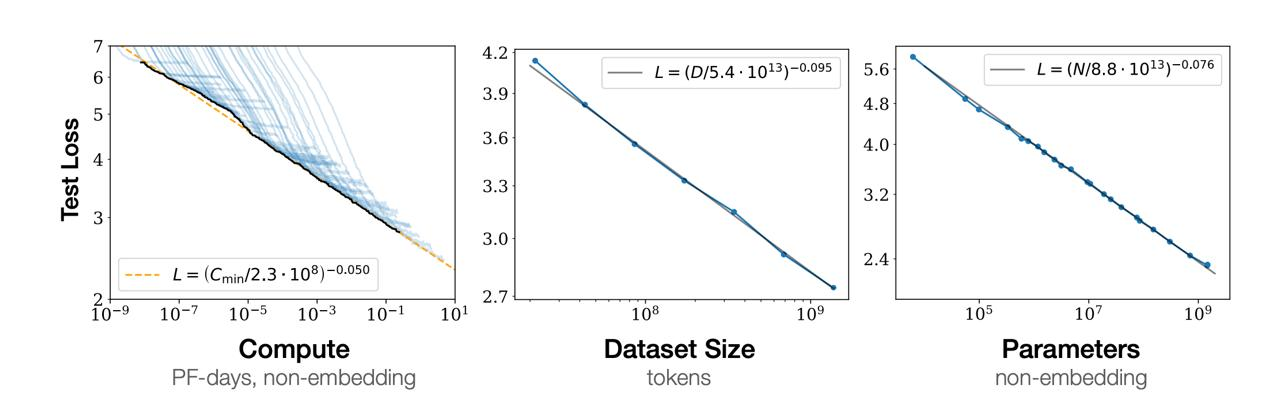

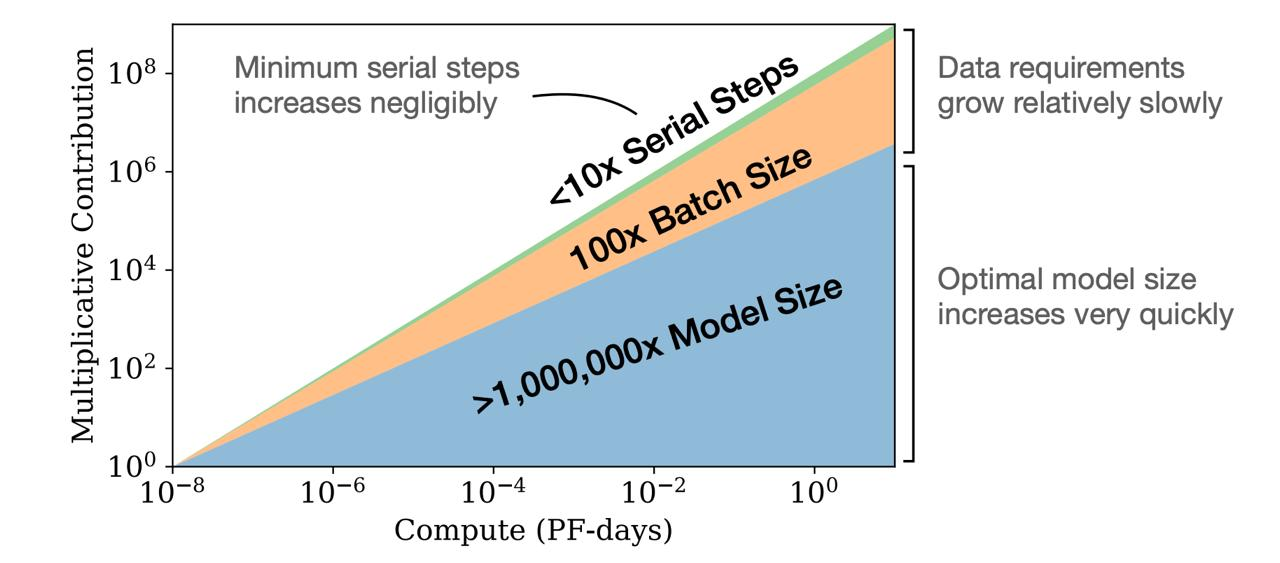

[Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361) ~8,000 цитирований

### Интуиция

Scaling laws отражают довольно простую идею: модель не "учится скачком", а постепенно улучшает аппроксимацию распределения данных по мере увеличения ресурсов.

Можно выделить несколько устойчивых эффектов:

1. **Убывающая отдача**
   - каждая дополнительная единица compute даёт всё меньший прирост качества
   - улучшения становятся более дорогими

2. **Роль масштаба**
   - маленькие модели быстро достигают предела выразительности
   - большие модели продолжают улучшаться, но требуют существенно больше данных и вычислений

3. **Баланс данных и параметров**
   - качество определяется не только размером модели, но и тем, насколько она "подкреплена" данными

Ключевой результат работы Chinchilla заключается в следующем наблюдении:

> многие крупные модели исторически были не оптимальны по распределению compute: они содержали слишком много параметров относительно объёма данных

Иначе говоря, модель может быть "слишком большой для своих данных", что приводит к недообучению.

### Оптимальность по compute (Chinchilla)

При фиксированном вычислительном бюджете существует оптимальный способ распределить ресурсы между $N$ и $D$.

Эмпирически это означает, что:

- нельзя бесконечно увеличивать параметры модели без увеличения данных
- оптимальная стратегия требует совместного масштабирования модели и датасета

### Практическая интерпретация

До появления scaling laws процесс обучения больших моделей был в значительной степени эмпирическим: архитектуры и размеры подбирались экспериментально.

Scaling laws изменили эту ситуацию:

- стало возможно заранее оценивать ожидаемый loss при заданном compute
- можно планировать размер модели и датасета до начала обучения
- оптимизация сместилась от "проб и ошибок" к бюджетному планированию

### Вывод

Законы масштабирования показывают, что:

- качество LLM предсказуемо зависит от $N$, $D$ и $C$
- улучшение качества подчиняется гладким степенным законам
- ключевая проблема обучения &ndash; не "как сделать модель больше", а как оптимально распределить compute


### Польза правил масштабирований

Scaling laws дают возможность частично переносить результаты с малых моделей на большие, но только в ограниченном смысле.

**Из этого следует практическое свойство:** если обучать несколько моделей разного размера на одинаковом распределении данных и фиксированном рецепте обучения, то зависимость loss от масштаба оказывается гладкой и предсказуемой в логарифмических координатах.

Это позволяет экстраполировать кривые качества: например, обучив малые модели $N_1, N_2, N_3$, можно аппроксимировать зависимость и оценить ожидаемый loss для более крупной модели $N \gg N_i$.

Отсюда возникает инженерная практика: проводить эксперименты на малых моделях, чтобы:

- оценить форму зависимости $L(N)$ и $L(D)$,
- выбрать оптимальное соотношение данных и параметров,
- оценить требуемый compute для достижения заданного качества.

Однако ключевое ограничение заключается в том, что scaling laws **описывают поведение функции потерь, а не дискретные способности модели**. То есть они хорошо предсказывают perplexity, но не гарантируют сохранение конкретных навыков при увеличении масштаба.

<font color='Red'>**Важно:**</font> Масштабирование &ndash; это основной механизм улучшения LLM, а архитектурные изменения без увеличения данных и compute дают ограниченный эффект.

## Supervised Fine-tuning (SFT)

После этапа предобучения языковая модель уже умеет моделировать текст и продолжать последовательности, однако её поведение не соответствует формату "вопрос $\to$ ответ" и не следует инструкциям напрямую. Иными словами,
> базовая модель оптимизирует вероятность продолжения текста, а не выполнения пользовательского запроса.

**Типичный пример поведения до SFT:**

Вход: "Кто автор стихотворения: У лукоморья дуб" \
Выход: "зеленый, златая цепь …"

### Цель обучения

**Цель SFT &ndash; адаптировать предобученную модель к распределению данных инструкций, где входом является запрос пользователя, а выходом &ndash; корректный ответ в нужном формате.**

**Формат данных**

Каждый пример $
(\text{prompt}, \text{response})
$ объединяется в последовательность:
$
\mathbf{x} = [x_1, x_2, \ldots, x_P, x_{P+1}, \ldots, x_T]
$ где $x_{1:P}$ &ndash; prompt, $x_{P+1:T}$ &ndash; response

**Функция потерь**

Ключевая особенность SFT заключается в том, что функция потерь считается только по токенам ответа, тогда как часть prompt используется как условие:

$$
L_{\text{SFT}}(\theta) =
- \sum_{t=P+1}^{T} \log P_\theta(x_t \mid x_{<t}).
$$
Таким образом, модель учится продолжать запрос правильным ответом, не оптимизируя напрямую сам prompt.

### Связь с предобучением

Для сравнения, при предобучении (next-token prediction) оптимизация проводится по всей последовательности:

$$
L_{\text{PT}}(\theta) =
- \sum_{t=1}^{T} \log P_\theta(x_t \mid x_{<t}).
$$

Различие принципиальное:

* pre-training учит моделировать распределение текста в целом,
* SFT переориентирует модель на условную генерацию ответов.

#### Источники данных для SFT

Подходы к построению датасетов:

- **Human labeling** &ndash; люди вручную пишут качественные ответы на инструкции  
  Пример моделей: InstructGPT (2022)

- **Distillation** &ndash; ответы генерируются сильной моделью и используются для обучения более слабой  
  Пример моделей: Alpaca (2023)

- **Self-instruct** &ndash; модель сама генерирует инструкции и ответы, после чего данные фильтруются  
  Пример моделей: Self-Instruct (2022)

- **Open datasets** &ndash; агрегированные и краудсорсинговые наборы данных  
  Пример моделей: FLAN (2022), OpenAssistant (2023)


#### Масштаб датасетов

- **InstructGPT (2022)** &ndash; примерно 13K вручную размеченных пар (~0.01–0.1M токенов)

- **Alpaca (2023)** &ndash; примерно 52K синтетически сгенерированных пар с помощью GPT-3.5 (~1-3M токенов)

- **FLAN / FLAN-T5 (2022)** &ndash; примерно 1M примеров (~10–100M токенов)

- **OpenAssistant (2023)** &ndash; примерно 160K диалогов (~20–100M токенов)



В статье InstructGPT показано, что модель с **1.3B параметров**, обученная с SFT + RLHF (поговорим далее), по человеческим предпочтениям превосходит базовый GPT-3 с **175B параметров**.

Это демонстрирует, что:

> качество и структура данных могут давать больший эффект, чем чистое увеличение масштаба модели.


<font color="orange">**Вопрос:**</font> Как думаете, какие ограничения у SFT?

#### Ограничения SFT

**Зависимость от качества данных.** Модель перенимает не только корректные паттерны, но и ошибки и предвзятости из разметки.

**Дорогая разметка.** Требуются эксперты, а создание качественных датасетов занимает много времени и ресурсов.

**Exposure bias.** На обучении &ndash; правильные последовательности, на инференсе &ndash; собственная генерация, из-за чего ошибки накапливаются.

**"Средние" ответы.** Оптимизация по токенам ведёт к усреднённым и безопасным формулировкам вместо лучших.

**Нет сигнала предпочтений.** Модель не различает "хороший" и "лучший" ответ &ndash; только воспроизводит "правильный".

**Ограниченная обобщаемость.**
Переобучение на стиль данных и слабая устойчивость к вне-доменам запросам.

## Alignment (выравнивание)

После этапа SFT модель уже умеет следовать инструкциям и выдавать корректные ответы, но остаётся ключевое ограничение: **корректный ответ не означает хороший ответ с точки зрения человека**.

Один и тот же запрос может иметь множество допустимых решений. Например, на вопрос про изучение DL можно ответить кратким списком шагов, подробным учебным планом или размытым описанием. Все эти варианты могут быть формально "правильными", но различаются по полезности, ясности, структуре и безопасности. SFT не различает такие варианты, потому что он учится воспроизводить конкретные примеры из данных, а не выбирать лучший среди возможных.

Поэтому вводится этап alignment (или выравнивание), где **цель смещается от имитации данных к приближению к человеческим предпочтениям**: модель должна не просто быть правильной, а быть предпочтительной для человека.

<font color="red">**Важно:**</font> Стоит заметить, что SFT иногда называют слабой фазой выравнивания.

### Формулируем задачу: что мы вообще оптимизируем?

Давайте подойдём к этому постепенно, отталкиваясь от того, что мы уже знаем.

### Что выдаёт наша модель?

Языковая модель &ndash; это распределение над ответами. Для запроса $x$ она задаёт вероятность каждого возможного ответа $y$:

$$\pi_\theta(y \mid x).$$

Здесь $\theta$ &ndash; параметры модели. Это не детерминированный алгоритм: на один и тот же вопрос модель может порождать разные ответы с разной вероятностью.

### Что мы хотим?

Мы хотим, чтобы модель давала **хорошие** ответы. Допустим, мы каким-то волшебным образом умеем измерять "хорошесть" ответа &ndash; пусть есть функция $R(y)$, которая возвращает скаляр: чем лучше ответ, тем больше значение.

Тогда наша цель записывается естественно:

$$\mathbb{E}_{y \sim \pi_\theta(y \mid x)}\left[ R(y) \right] \to \max_\theta$$

Мы хотим подобрать параметры $\theta$ так, чтобы в среднем по ответам, которые порождает модель, "хорошесть" была максимальной.

### Чем это отличается от привычных задач DL?

Давайте вспомним, как выглядит типичная задача глубокого обучения. У нас есть датасет, и мы минимизируем:

$$\mathbb{E}_{(x,y) \sim D}\left[ L(f_\theta(x), y) \right] \to \min_\theta$$

Параметры $\theta$ сидят **внутри функции** $f_\theta$, а математическое ожидание берётся по **фиксированному распределению данных** $D$, которое от $\theta$ не зависит. Поэтому мы спокойно меняем местами градиент и матожидание:

$$\nabla_\theta \, \mathbb{E}_{(x,y) \sim D}\left[ L \right] = \mathbb{E}_{(x,y) \sim D}\left[ \nabla_\theta \, L \right]$$

и оцениваем градиент по мини-батчу. Всё работает.

### А в чём проблема у нас?

Посмотрите ещё раз на нашу цель:

$$\mathbb{E}_{y \sim \pi_\theta(y \mid x)}\left[ R(y) \right]$$

Параметры $\theta$ теперь сидят **в самом распределении**, по которому берётся математическое ожидание. Распределение зависит от $\theta$, поэтому мы **не можем** просто сказать, что "градиент матожидания равен матожиданию градиента". Привычный трюк с мини-батчем напрямую не работает.

Более того, функция $R(y)$ может быть вообще **недифференцируемой** &ndash; например, это оценка человека или бинарный сигнал "хорошо / плохо".

Именно такой сеттинг изучает **обучение с подкреплением (Reinforcement Learning)**. В терминологии RL:

- $\pi_\theta$ &ndash; **политика** (policy): стратегия выбора действий (в нашем случае &ndash; генерация ответа)
- $R$ &ndash; **награда** (reward): сигнал качества (в нашем случае &ndash; "хорошесть" ответа)

RL разработало целый арсенал методов для оптимизации ожидаемой награды, даже когда $R$ недифференцируема и распределение зависит от параметров.

В магистратуре будет отдельный курс RL, на котором вы подробнее познакомитесь с терминологией и методами.

### Как учить функцию "хорошести"?

Хорошо, мы поняли, что хотим максимизировать $\mathbb{E}[R(y)]$, и даже знаем, что RL поможет с оптимизацией. Но остаётся вопрос: **откуда взять $R(y)$?**

Можно попробовать обучить модель, которая принимает текст и выдаёт число &ndash; "насколько хорош этот ответ". Но подумайте: как бы вы собрали для этого данные?

Попробуйте объяснить асессору: "оцени этот ответ по шкале от 0 до 10". Что такое 7? Чем 6 отличается от 7? Один асессор ставит 8, другой за тот же ответ &ndash; 5. Абсолютная шкала качества текста &ndash; вещь крайне субъективная и нестабильная.

Но вот что люди умеют делать хорошо: **сравнивать**. Покажите человеку два ответа на один и тот же вопрос, и он уверенно скажет, какой лучше. Это проще, надёжнее и даёт гораздо более согласованные данные между разными асессорами.


### Данные предпочтений

Поэтому используется относительная форма сигнала. Для одного запроса берутся два ответа:

$$(x, y^+, y^-),$$
где $y^+$ предпочтительнее $y^-$ по оценке человека. Здесь не требуется абсолютная шкала качества &ndash; достаточно уметь сравнивать два варианта.

### Reward model

Но для оптимизации нам всё-таки нужен скалярный сигнал. Поэтому мы обучаем **модель награды** (reward model):

$$r_\phi(x, y).$$

Она принимает запрос и ответ и выдаёт число. Важна не абсолютная величина этого числа, а **разница между ответами**: если $y^+$ лучше $y^-$, то $r_\phi(x, y^+)$ должно быть больше $r_\phi(x, y^-)$.

Формально: вероятность того, что модель правильно предскажет предпочтение, задаётся через сигмоиду от разности оценок:

$$P(y^+ \succ y^- \mid x) = \sigma\bigl(r_\phi(x, y^+) - r_\phi(x, y^-)\bigr).$$

Чем больше оценка у $y^+$ по сравнению с $y^-$, тем ближе вероятность к единице; если модель ошибается &ndash; разность становится отрицательной и вероятность падает.

Обучение reward model сводится к максимизации этой вероятности, что эквивалентно минимизации логистической функции потерь:

$$L_{RM} = -\log \sigma\bigl(r_\phi(x, y^+) - r_\phi(x, y^-)\bigr).$$

### Reinforcement learning with Human Feedback

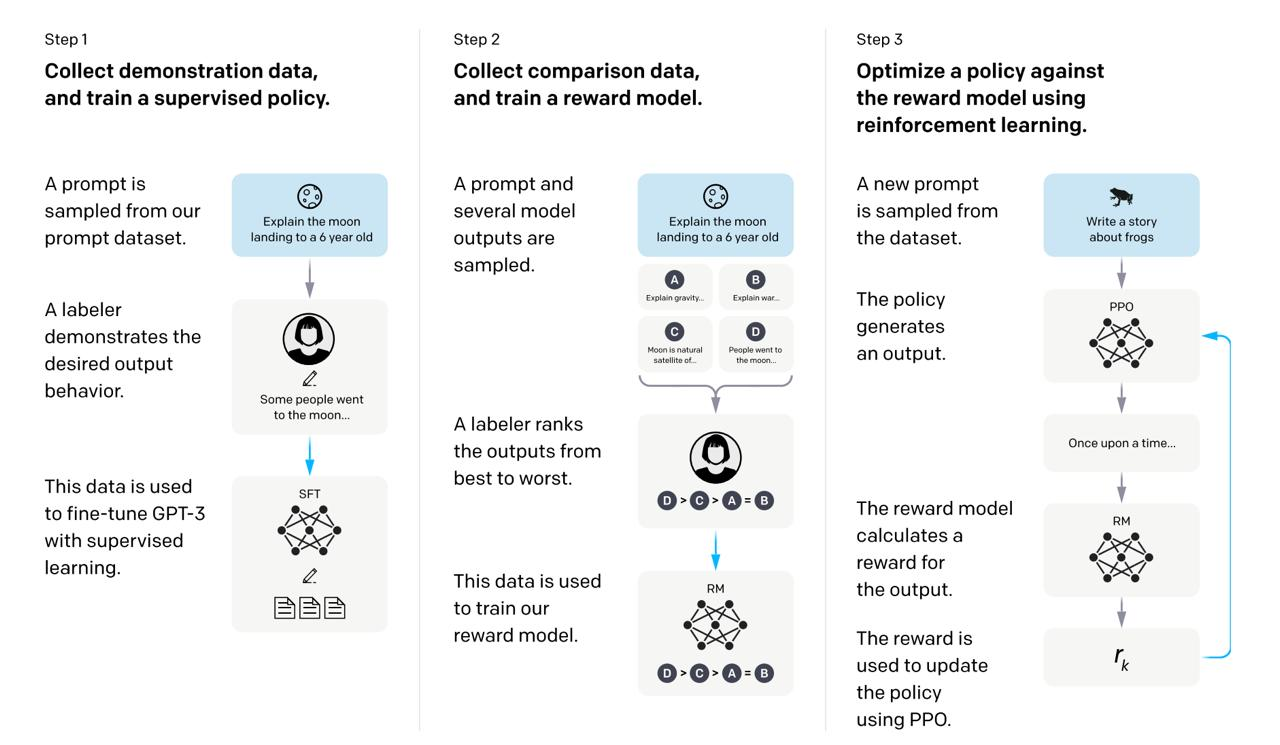

RLHF из [Training language models to follow instructions with human feedback (InstructGPT)](https://arxiv.org/abs/2203.02155) ~24,000 цитирований

## RLHF: обучение на предпочтениях человека

### Напомним, где мы остановились

Мы хотим оптимизировать:

$$\mathbb{E}_{y \sim \pi_\theta(y \mid x)}\left[ R(y) \right] \to \max_\theta$$

И мы выяснили две вещи:

1. **Функцию "хорошести" $R(y)$** мы умеем приближать через reward model $r_\phi(x, y)$, обученную на парных сравнениях людей.
2. **Оптимизировать эту цель напрямую** нельзя так же, как в обычном DL, потому что параметры $\theta$ сидят в распределении $\pi_\theta$, по которому берётся матожидание. Градиент матожидания $\neq$ матожидание градиента.

Этим занимается RL. Но у RL-оптимизации есть своя центральная боль.


### Главная проблема: дисперсия

Раз мы не можем аналитически посчитать $\nabla_\theta \mathbb{E}_{\pi_\theta}[R(y)]$, мы вынуждены **оценивать градиент стохастически** &ndash; сэмплируя ответы из модели и используя их для приближения. Проблема в том, что такие оценки градиента имеют **огромную дисперсию**. Модель генерирует длинные тексты, пространство возможных ответов колоссально, и один-два сэмпла дают очень шумный сигнал о том, куда двигать параметры.

На практике это означает, что наивная RL-оптимизация **постоянно разваливается**: модель скачет, не сходится, или находит дегенеративные способы получить высокий reward (например, повторяет одну и ту же фразу, которая случайно понравилась reward model).

Мы разберём два ключевых трюка, которые помогают с этим бороться. Но важно понимать: мы здесь **не будем** доказывать, почему эти трюки дают несмещённую оценку градиента и почему метод сходится. Это отдельная и глубокая тема &ndash; вы встретите её на курсах по RL с полноценными теоремами. Наша цель &ndash; дать интуицию, достаточную для понимания пайплайна обучения LLM.


## RLHF-пайплайн: три этапа

RLHF реализуется как трёхэтапный процесс:

**Этап 1: SFT $\to$ референсная модель**

Берём базовую языковую модель и дообучаем её на парах (инструкция $\to$ ответ). Получаем модель, которая умеет следовать инструкциям:

$$\pi_{\text{ref}}$$

Это наша отправная точка &ndash; модель, которая уже "адекватна", но ещё не оптимизирована под предпочтения.

**Этап 2: Reward model**

Собираем сравнения ответов $(x, y^+, y^-)$ и обучаем модель оценки $r_\phi(x, y)$, как описано выше. Она учится предсказывать, какой ответ человек предпочёл.

**Этап 3: RL-оптимизация**

Теперь мы хотим улучшить политику $\pi_\theta$ (инициализированную из $\pi_{\text{ref}}$), чтобы она генерировала ответы с высоким reward:

$$\max_\theta \; \mathbb{E}_{y \sim \pi_\theta(y \mid x)}\left[ r_\phi(x, y) \right]$$

Именно на этом этапе используется алгоритм **PPO**.

## PPO (Proximal Policy Optimization)

### Шаг 1: сэмплирование

Для запроса $x$:
- генерируем ответ $y \sim \pi_\theta$
- считаем reward: $r_\phi(x, y)$
- запоминаем вероятности текущей политики $\pi_\theta(y \mid x)$

### Шаг 2: importance sampling

После того как мы собрали батч ответов, мы хотим сделать несколько шагов оптимизации на этих данных (а не выбрасывать их после одного обновления &ndash; сэмплирование дорогое!). Но после первого обновления параметры изменились: у нас уже $\pi_\theta$, а данные были собраны из $\pi_{\text{old}}$.

PPO использует классический трюк &ndash; **importance sampling**: пересчитывает вклад каждого сэмпла через отношение вероятностей:

$$r_t = \frac{\pi_\theta(y \mid x)}{\pi_{\text{old}}(y \mid x)}$$

- $r_t > 1$ &ndash; новая политика считает этот ответ более вероятным, чем старая
- $r_t < 1$ &ndash; менее вероятным

Этот трюк позволяет переиспользовать сэмплы и **уменьшить дисперсию** оценки градиента. Вы познакомитесь с importance sampling подробнее на курсе байесовских методов машинного обучения.

### Шаг 3: clipping &ndash; ещё один способ снизить дисперсию

Importance sampling помогает, но у него есть известная проблема: когда $r_t$ становится очень большим или очень маленьким, дисперсия оценки снова взлетает. Один "неудачный" сэмпл с экстремальным весом может сломать всё обновление.

PPO решает это clipping-ом:

$$L^{CLIP} = \min \big(r_t A_t,\; \text{clip}(r_t,\; 1-\epsilon,\; 1+\epsilon) \cdot A_t \big)$$

где $A_t$ &ndash; **advantage**: насколько данный ответ лучше или хуже среднего (по оценке reward model).

Что здесь происходит:
- Если $r_t$ уходит за пределы $[1-\epsilon, 1+\epsilon]$, он обрезается
- Это значит: даже если новая политика сильно отличается от старой для какого-то сэмпла, мы **ограничиваем его влияние** на градиент
- Типичное значение $\epsilon = 0.2$, то есть вероятности не могут измениться более чем на 20%

Оба трюка &ndash; importance sampling и clipping &ndash; направлены на одно и то же: **сделать оценку градиента менее шумной**, чтобы оптимизация сходилась, а не разваливалась.

### Что в итоге оптимизирует PPO?

Собирая всё вместе, на каждом шаге PPO максимизирует:

$$L^{PPO} = \mathbb{E}_{y \sim \pi_{\text{old}}} \left[ \min \big(r_t A_t,\; \text{clip}(r_t,\; 1-\epsilon,\; 1+\epsilon) \cdot A_t \big) \right]$$

где:
- $r_t = \frac{\pi_\theta(y \mid x)}{\pi_{\text{old}}(y \mid x)}$ &ndash; отношение вероятностей (importance sampling)
- $A_t$ &ndash; advantage, оценённый через reward model
- $\text{clip}$ &ndash; обрезка, не дающая одному сэмплу сломать обучение

Это суррогат исходной функции потерь $\mathbb{E}_{\pi_\theta}[R(y)]$, но с двумя встроенными механизмами контроля дисперсии.

### KL-штраф: не уходи далеко от исходной модели

Есть ещё одна проблема. Даже если PPO стабильно оптимизирует reward, модель может найти "лазейки" в reward model &ndash; паттерны текста, которые получают высокую оценку, но на самом деле бессмысленны или вырождены. Reward model несовершенна, и если давать модели полную свободу, она это эксплуатирует.

Поэтому в целевую функцию добавляется **KL-штраф** к референсной модели:

$$\max_\theta \; \mathbb{E}_{y \sim \pi_\theta}\left[ r_\phi(x, y) \right] - \beta \cdot \text{KL}\left(\pi_\theta \;\|\; \pi_{\text{ref}}\right)$$

KL-дивергенция измеряет, насколько новая политика $\pi_\theta$ отличается от исходной $\pi_{\text{ref}}$. Штраф говорит: **улучшай ответы, но не уходи далеко от нормальной модели**.

Это не просто регуляризация "на всякий случай" &ndash; без KL-штрафа RLHF на практике быстро деградирует.

На практике KL-штраф добавляется прямо в reward на каждом шаге, и PPO оптимизирует модифицированную награду:

$$\tilde{r}(x, y) = r_\phi(x, y) - \beta \cdot \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}$$

Таким образом, **итоговый objective всего RLHF-пайплайна**:

$$\max_\theta \; \mathbb{E}_{y \sim \pi_\theta}\left[ r_\phi(x, y) - \beta \cdot \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)} \right]$$

который оптимизируется через PPO с importance sampling и clipping.

> Мы здесь дали интуицию о пайплайне RLHF &ndash; достаточную, чтобы понимать, как обучаются современные LLM. Но под капотом остаётся очень много: почему REINFORCE даёт несмещённый градиент, как именно считается advantage, почему clipping не ломает сходимость, как бороться с reward hacking, как масштабировать PPO на модели с миллиардами параметров. Всё это &ndash; темы полноценных курсов по RL и NLP.


## DPO (Direct Preference Optimization)

### Мотивация: а можно проще?

Давайте посмотрим на RLHF-пайплайн и подумаем, что в нём сложного:

1. Нужно **обучить отдельную reward model** &ndash; это отдельная модель с отдельным обучением
2. Нужно **запустить PPO** &ndash; а это итеративный цикл: сэмплируем ответы, считаем reward, оцениваем advantage, обновляем политику, повторяем
3. Нужно **бороться с дисперсией** &ndash; importance sampling, clipping, подбор гиперпараметров
4. Нужно **балансировать reward и KL-штраф** &ndash; чтобы модель не эксплуатировала reward model

Всё это работает, но требует огромных вычислительных ресурсов, тонкой настройки и инженерной экспертизы. Возникает вопрос: **можно ли получить тот же результат проще?**

DPO (Direct Preference Optimization) отвечает: **да** &ndash; можно убрать reward model и PPO целиком, и обучать модель на предпочтениях напрямую, как обычную supervised задачу.

### Ключевое наблюдение

Вспомним, что в RLHF мы оптимизируем:

$$\max_\theta \; \mathbb{E}_{y \sim \pi_\theta}\left[ r_\phi(x, y) \right] - \beta \cdot \text{KL}\left(\pi_\theta \;\|\; \pi_{\text{ref}}\right)$$

Оказывается, что для этой задачи можно **аналитически выписать оптимальное решение** &ndash; выразить оптимальную политику $\pi^*$ через reward model $r_\phi$ и референсную модель $\pi_{\text{ref}}$. А затем &ndash; перевернуть эту формулу и **выразить reward через политику**. Это позволяет подставить выражение для reward обратно в функцию потерь reward model и получить лосс, который зависит **только от политики $\pi_\theta$ и референса $\pi_{\text{ref}}$** &ndash; без reward model вообще.

Вывод этой формулы &ndash; красивое упражнение на вариационное исчисление, но мы здесь приведём результат.

### Функция потерь DPO

Исходные данные &ndash; те же пары предпочтений:

$$(x, y^+, y^-),$$
где $y^+$ предпочтительнее $y^-$ по оценке человека.

Функция потерь:

$$L_{\text{DPO}} = -\log \sigma \Big( \beta \big[ \log \pi_\theta(y^+ \mid x) - \log \pi_\theta(y^- \mid x) - \big(\log \pi_{\text{ref}}(y^+ \mid x) - \log \pi_{\text{ref}}(y^- \mid x)\big) \big] \Big)$$

Давайте разберём, что здесь происходит.

**Внутренняя часть** &ndash; это разность лог-отношений:

$$\underbrace{\log \frac{\pi_\theta(y^+ \mid x)}{\pi_\theta(y^- \mid x)}}_{\text{текущая модель: насколько } y^+ \text{ вероятнее } y^-} \;-\; \underbrace{\log \frac{\pi_{\text{ref}}(y^+ \mid x)}{\pi_{\text{ref}}(y^- \mid x)}}_{\text{референс: насколько } y^+ \text{ вероятнее } y^- \text{ в SFT}}$$

Что это значит:
- Модель должна делать $y^+$ более вероятным, чем $y^-$
- Но не просто "усиливать хороший ответ" &ndash; а **усиливать его сверх того, что уже делала SFT-модель**
- Вычитание референса играет ту же роль, что KL-штраф в RLHF: не даёт модели уйти далеко от базового поведения

Коэффициент $\beta$ контролирует, насколько сильно модель может отклоняться от референса (аналог $\beta$ в KL-штрафе RLHF &ndash; это не совпадение, это тот же самый параметр).

### Почему это работает?

Сигмоида $\sigma(\cdot)$ превращает разность в вероятность, а $-\log$ делает из этого лосс. Структура получается той же, что у reward model:

| | Reward model | DPO |
|---|---|---|
| Внутри $\sigma$ | $r_\phi(x, y^+) - r_\phi(x, y^-)$ | $\beta \left[\log \frac{\pi_\theta(y^+\mid x)}{\pi_{\text{ref}}(y^+\mid x)} - \log \frac{\pi_\theta(y^-\mid x)}{\pi_{\text{ref}}(y^-\mid x)}\right]$ |
| Что оптимизируется | Параметры reward model $\phi$ | Параметры политики $\theta$ |

DPO по сути говорит: **сама политика и есть reward model** &ndash; не нужно обучать отдельную модель оценки, можно извлечь сигнал предпочтений напрямую из логарифмов вероятностей.

### Сравнение с RLHF

| | RLHF (PPO) | DPO |
|---|---|---|
| Reward model | Нужна, обучается отдельно | Не нужна |
| RL-оптимизация | PPO с сэмплированием | Нет &ndash; обычный supervised лосс |
| Генерация ответов в цикле | Да, на каждом шаге | Нет &ndash; используются заранее собранные пары |
| Сложность реализации | Высокая | Низкая &ndash; почти как SFT |
| KL-регуляризация | Явный штраф в objective | Встроена через референсную модель в лоссе |

### Интуиция

DPO можно понимать так:

- **SFT** задаёт базовую модель поведения
- **Референс $\pi_{\text{ref}}$** фиксирует "норму" &ndash; что модель умела до выравнивания
- **DPO** сдвигает модель так, чтобы она чаще выбирала предпочтительные ответы **относительно этой нормы**

Это элегантное решение: вместо сложного RL-пайплайна &ndash; один supervised лосс, который теоретически оптимизирует тот же objective. На практике DPO проще в реализации, стабильнее в обучении и требует меньше вычислений, что сделало его очень популярным.

> **Замечание.** DPO &ndash; не единственная альтернатива RLHF. Существует целое семейство методов прямой оптимизации предпочтений (IPO, KTO, ORPO и другие), каждый со своими компромиссами. Кроме того, на практике DPO и RLHF могут давать разные результаты &ndash; что лучше, зависит от задачи, данных и масштаба. Мы разобрали основные идеи, но нюансов хватает на отдельный курс.

## Адаптация во время инференса

### In-Context learning

Одним из ключевых свойств современных LLM является способность к **In-Context Learning (ICL)** &ndash; обучению на лету без обновления параметров модели. Вместо изменения весов, **модель использует сам контекст запроса как источник "временных данных обучения"**: в промпт добавляются несколько примеров вида *(input $\to$ output)*, и модель продолжает последовательность, обобщая наблюдаемый шаблон.

С формальной точки зрения, задача не меняется: модель по-прежнему максимизирует вероятность следующего токена

$$P(x_t \mid x_{<t}),$$

но теперь в $x_{<t}$ уже зашиты демонстрации решения задачи. Таким образом, обучение переносится из параметров модели в пространство контекста.

<font color="red">**Важно:**</font> Во время pre-training модель обучается распознавать паттерны "задача $\to$ решение" внутри текста и затем воспроизводить их при инференсе. Поэтому ICL работает особенно хорошо, когда формат задачи совпадает с тем, что встречался в обучающих данных.

#### Почему ICL вообще работает?

Механизм ICL до сих пор является предметом активных исследований, но одна из гипотез &ndash; **ICL &ndash; неявный градиентный спуск**.

В статье [Why Can GPT Learn In-Context? Language Models Secretly Perform Gradient Descent as Meta-Optimizers](https://arxiv.org/abs/2212.10559) показали, что механизм внимания в трансформере имеет двойственную форму с градиентным спуском. В этой интерпретации, когда модель обрабатывает примеры в контексте, GPT сначала порождает мета-градиенты на основе демонстрационных примеров, а затем эти мета-градиенты применяются к исходной модели, формируя ICL-модель. По сути, модель как бы «дообучается» на примерах из промпта, но без реального обновления весов &ndash; всё происходит внутри одного forward pass.

Экспериментально авторы сравнили поведение ICL и явного fine-tuning на реальных задачах и показали, что ICL ведёт себя аналогично fine-tuning на уровне предсказаний, представлений и паттернов внимания.

Независимо к схожему выводу пришли [Transformers Learn In-Context by Gradient Descent](https://arxiv.org/abs/2212.07677): обучение трансформеров на авторегрессионных задачах тесно связано с формулировками мета-обучения на основе градиентного спуска, и для одного линейного слоя self-attention можно показать эквивалентность с шагом градиентного спуска на регрессионном лоссе. Более того, авторы показали, как трансформеры превосходят обычный градиентный спуск, обучаясь итеративной коррекции кривизны.

Важно понимать ограничения этой теории: доказательства эквивалентности ICL и градиентного спуска получены при сильных предположениях, на упрощённых моделях (линейный attention, простые регрессионные задачи). Экстраполяция на полноценные LLM остаётся открытым вопросом.

#### Ограничения ICL

Однако у подхода есть ограничения:
- качество сильно зависит от формулировки и порядка примеров (чувствительность к prompt design),
- объём "обучения" ограничен длиной контекста,
- обобщение нестабильно: модель скорее имитирует шаблон, чем действительно "учится".

Важно, что ICL и fine-tuning решают схожую задачу разными способами:
- **fine-tuning** &ndash; обновляет параметры и даёт устойчивое поведение,
- **ICL** &ndash; быстрый и гибкий, но менее надёжный способ адаптации.

В результате ICL можно рассматривать как механизм быстрого прототипирования поведения модели, тогда как fine-tuning &ndash; как способ его закрепления.


### Chain-of-Thought (CoT)

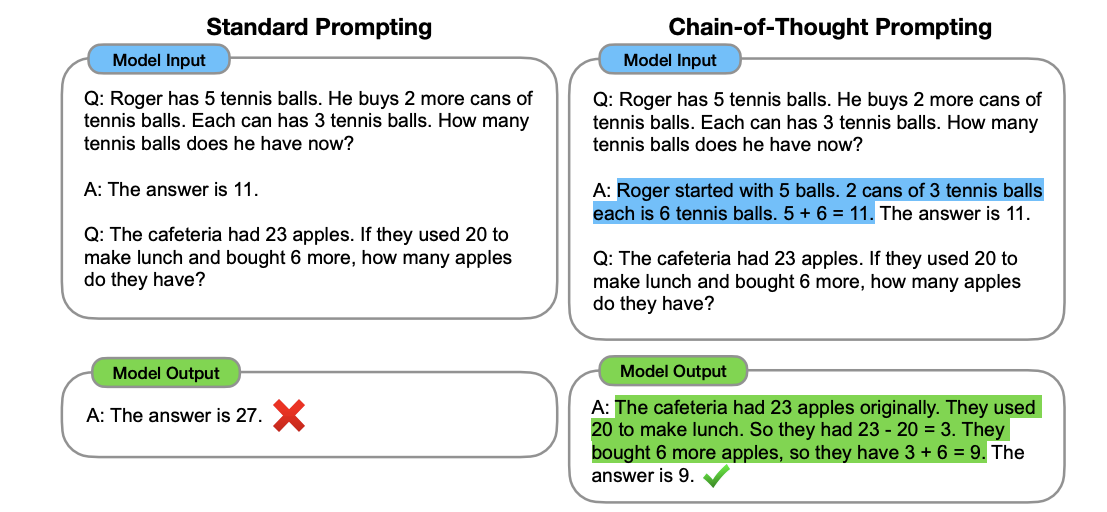

[Language Models Perform Reasoning via Chain of Though](https://research.google/blog/language-models-perform-reasoning-via-chain-of-thought/)

Обычные LLM формируют ответ, опираясь на вероятностное распределение следующего токена, что хорошо работает для простых или шаблонных задач. Однако при решении задач, требующих многошаговых рассуждений, такой подход часто даёт ошибки: модель может "перепрыгнуть" через промежуточные выводы или выбрать наиболее вероятный, но неверный ответ.

**Chain-of-Thought (CoT)** &ndash; это техника, при которой **модель явно генерирует промежуточные шаги рассуждения перед финальным ответом**. По сути, мы заставляем модель не просто предсказать ответ, а развернуть скрытое рассуждение в последовательность логических операций.

Это даёт несколько эффектов:

* снижает вероятность логических ошибок за счёт декомпозиции задачи
* улучшает обобщающую способность на задачах, отличающихся от обучающих
* делает поведение модели частично интерпретируемым (можно увидеть, где она ошиблась)

Важно, что CoT &ndash; это не изменение архитектуры модели, а **способ промптинга или обучения**. Он работает особенно хорошо для:

* арифметики и алгебры,
* задач на логические выводы,
* задач с несколькими зависимыми условиями.

Однако у метода есть ограничения:
* модель может генерировать правдоподобные, но неверные рассуждения (illusion of reasoning);
* длинные цепочки увеличивают стоимость и время инференса;
* CoT не гарантирует корректность &ndash; он лишь повышает вероятность правильного ответа.

## Parameter-Efficient Fine-Tuning (PEFT)

После предобучения и SFT/Alignment возникает практическая проблема: обновление всех параметров модели становится крайне дорогим.

Для современных LLM это означает:

* десятки/сотни миллиардов параметров
* высокая стоимость GPU-памяти и оптимизации
* необходимость хранить отдельную копию модели под каждую задачу
* риск катастрофического забывания при дообучении.

**Full fine-tuning плохо масштабируется как по вычислениям, так и по продуктовой инфраструктуре.**

**PEFT** &ndash; это семейство методов, в которых мы не обновляем всю модель, а обучаем только малую добавку к ней (обычно <1–5% параметров).

**Идея:**
> базовая модель остаётся замороженной, а адаптация происходит через небольшие обучаемые компоненты.

На практике это означает, что вместо переобучения всей сети мы "настраиваем поведение" модели через компактный набор параметров, который кодирует нужный сдвиг под задачу или домен.

Интуитивно: модель уже содержит необходимые знания после pre-training, и PEFT лишь добавляет небольшой “механизм перенастройки”, не затрагивая основную память модели.

Наиболее распространённые подходы:

* LoRA (низкоранговые добавки к весам)
* Adapter-based методы (вставка небольших блоков в трансформер)
* Prompt tuning (обучаемые виртуальные токены)
* Prefix tuning (обучаемые префиксы attention)

<font color='Red'>**Важно:**</font> **Ключевое преимущество PEFT** &ndash; возможность хранить и переключать множество адаптаций одной и той же базовой модели без её копирования.

Подробнее про конкретные методы, их устройство и практические trade-offs будет на отдельной лекции.


## Заключение


В лекции мы разобрали полный цикл обучения современных LLM &ndash; от предобучения до выравнивания под человеческие предпочтения. Pre-training строит базовую языковую модель, SFT переводит её в режим следования инструкциям, а alignment (RLHF/DPO) настраивает поведение под предпочтения человека. Дополнительно рассмотрели адаптацию без изменения весов (ICL, CoT) и эффективные методы дообучения (PEFT).

Важно, что качество LLM определяется не только архитектурой, но и данными, их балансировкой, масштабом и самим процессом обучения. Именно комбинация этих факторов определяет итоговые способности модели.

В результате современная LLM &ndash; это не единая сущность, а многоэтапный пайплайн, где каждый этап отвечает за свой аспект поведения и качества.